In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/feature_engineered_data/dataco_feature_engineered.csv")

In [3]:
df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_name,customer_city,customer_country,...,order_year,order_month_name,order_quarter,order_day_name,shipping_duration_days,is_weekend_order,profit_margin_percentage,discount_amount,delivery_delay_days,is_late_delivery
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,2018,January,1,Wednesday,3,False,29.0,13.11,-1,False
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,2018,January,1,Saturday,5,True,-80.0,16.39,1,True
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,2018,January,1,Saturday,4,True,-80.0,18.03,0,False
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,2018,January,1,Saturday,3,True,7.5,22.94,-1,False
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,2018,January,1,Saturday,2,True,45.0,29.50,-2,False


In [4]:
df.shape

(180519, 50)

In [5]:
df.describe()

,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,late_delivery_risk,customer_id,latitude,longitude,order_customer_id,order_id,...,sales,order_item_total,order_profit_per_order,product_price,order_year,order_quarter,shipping_duration_days,profit_margin_percentage,discount_amount,delivery_delay_days
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,6691.379495,29.719955,-84.915675,6691.379495,36221.894903,...,203.772096,183.107609,21.974989,141.232550,2015.971150,2.417319,3.471856,12.044739,46.038713,0.565807
std,1.623722,1.374449,104.433526,120.043670,0.497664,4162.918106,9.813646,21.433241,4162.918106,21045.379569,...,132.273077,120.043670,104.433526,139.732492,0.829429,1.096876,1.670471,46.665829,65.584954,1.490966
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,1.000000,-33.937553,-158.025986,1.000000,1.000000,...,9.990000,7.490000,-4274.979980,9.990000,2015.000000,1.000000,0.000000,-275.080000,0.000000,-2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,3258.500000,18.265432,-98.446312,3258.500000,18057.000000,...,119.980003,104.379997,7.000000,50.000000,2015.000000,1.000000,2.000000,7.500000,8.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,6457.000000,33.144863,-76.847908,6457.000000,36140.000000,...,199.919998,163.990005,31.520000,59.990002,2016.000000,2.000000,3.000000,27.000000,22.500000,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,9779.000000,39.279617,-66.370583,9779.000000,54144.000000,...,299.950012,247.399994,64.800003,199.990005,2017.000000,3.000000,5.000000,36.300000,54.000000,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,20757.000000,48.781933,115.263077,20757.000000,77204.000000,...,1999.989990,1939.989990,911.799988,1999.989990,2018.000000,4.000000,6.000000,50.060000,625.000000,4.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 50 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  str    
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  str    
 6   late_delivery_risk           180519 non-null  int64  
 7   category_name                180519 non-null  str    
 8   customer_city                180519 non-null  str    
 9   customer_country             180519 non-null  str    
 10  customer_id                  180519 non-null  int64  
 11  customer_segment             180519 non-null  str    
 12  customer_street              180519 non-null  str    
 13  latitude  

In [7]:
df.isnull().sum()

type                           0
days_for_shipping_real         0
days_for_shipment_scheduled    0
benefit_per_order              0
sales_per_customer             0
delivery_status                0
late_delivery_risk             0
category_name                  0
customer_city                  0
customer_country               0
customer_id                    0
customer_segment               0
customer_street                0
latitude                       0
longitude                      0
market                         0
order_city                     0
order_country                  0
order_customer_id              0
order_date_dateorders          0
order_id                       0
order_item_cardprod_id         0
order_item_discount            0
order_item_discount_rate       0
order_item_id                  0
order_item_product_price       0
order_item_profit_ratio        0
order_item_quantity            0
sales                          0
order_item_total               0
order_prof

In [8]:
df.duplicated().sum()

np.int64(0)

 Has the average discount changed over time?

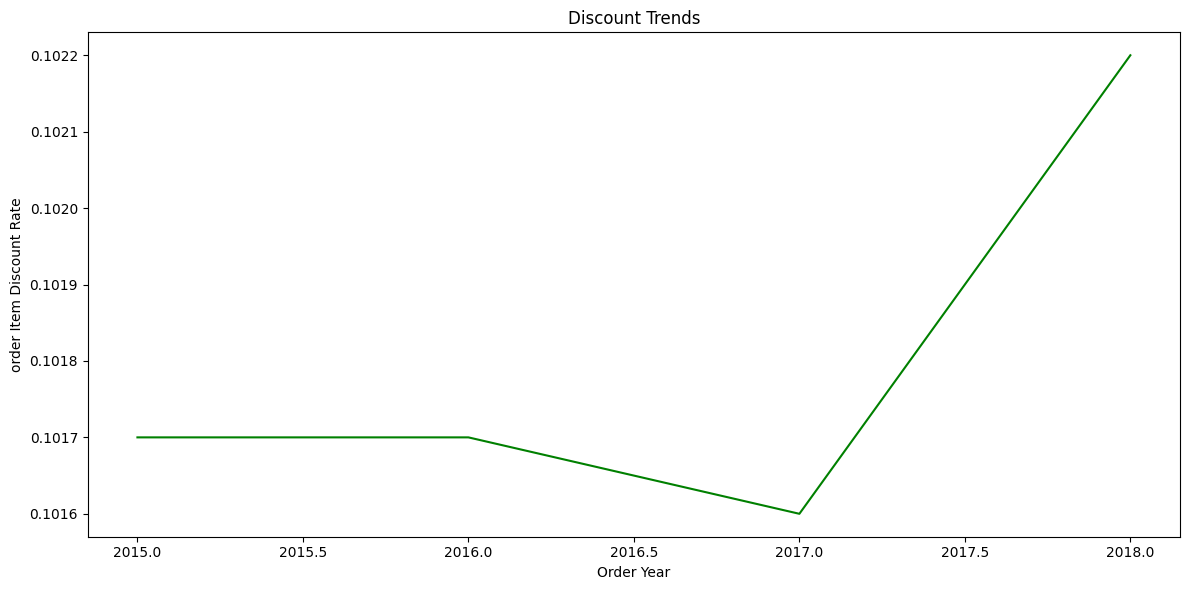

In [9]:
discount_trends = (
    df.groupby("order_year")["order_item_discount_rate"]
      .mean()
      .reset_index()
      .round(4)
)
plt.figure(figsize = (12,6))
sns.lineplot(x= "order_year", y= "order_item_discount_rate",data = discount_trends,color = "green")
plt.title("Discount Trends")
plt.xlabel("Order Year")
plt.ylabel("order Item Discount Rate")
plt.tight_layout()
plt.show()

-- Business Insight:

The average discount remained stable across all years, indicating a consistent pricing strategy.

 No significant increase or decrease in discounts was observed over time.

Which product categories require the highest average discounts?

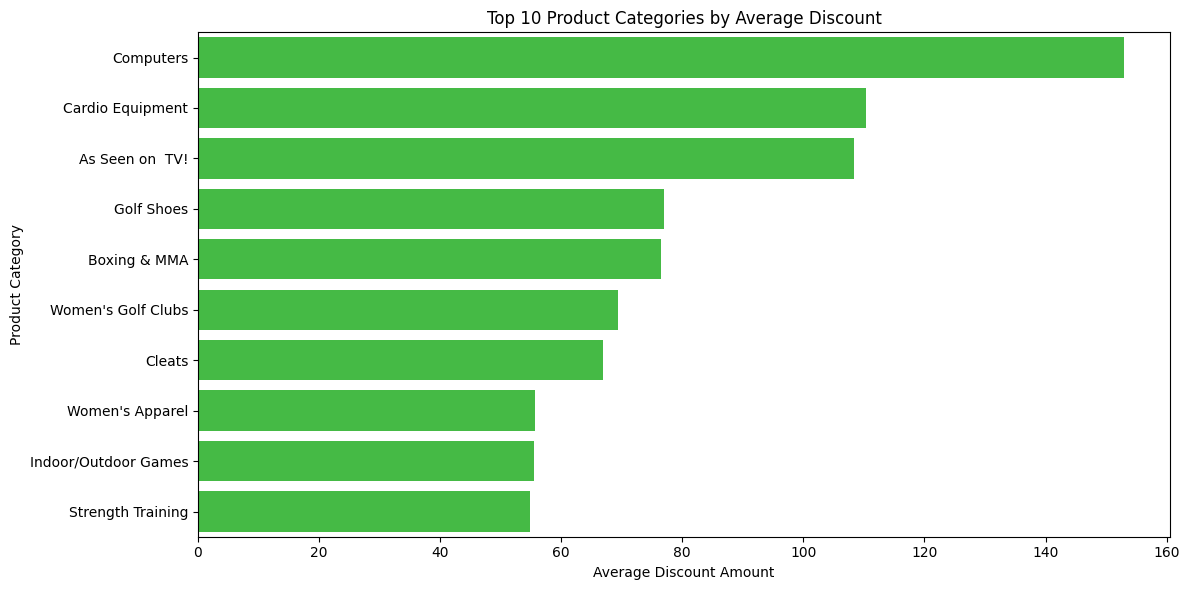

In [10]:
highest_avg_discount = (
        df.groupby("category_name")["discount_amount"]
          .mean()
          .round(2)
          .reset_index()
          .sort_values(by = "discount_amount", ascending = False)
          .head(10)
          
)

plt.figure(figsize = (12,6))
sns.barplot(data = highest_avg_discount,
            x = "discount_amount",
            y = "category_name",
            color = "limegreen")
plt.title("Top 10 Product Categories by Average Discount")
plt.xlabel("Average Discount Amount")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

-- Business Insight:

Categories such as Computers and Cardio Equipment receive the highest average discounts, indicating they rely more heavily on discounting than other categories. 

These categories should be reviewed to ensure that higher discounts are translating into stronger sales and healthy profitability.

Which markets require the highest average discounts?

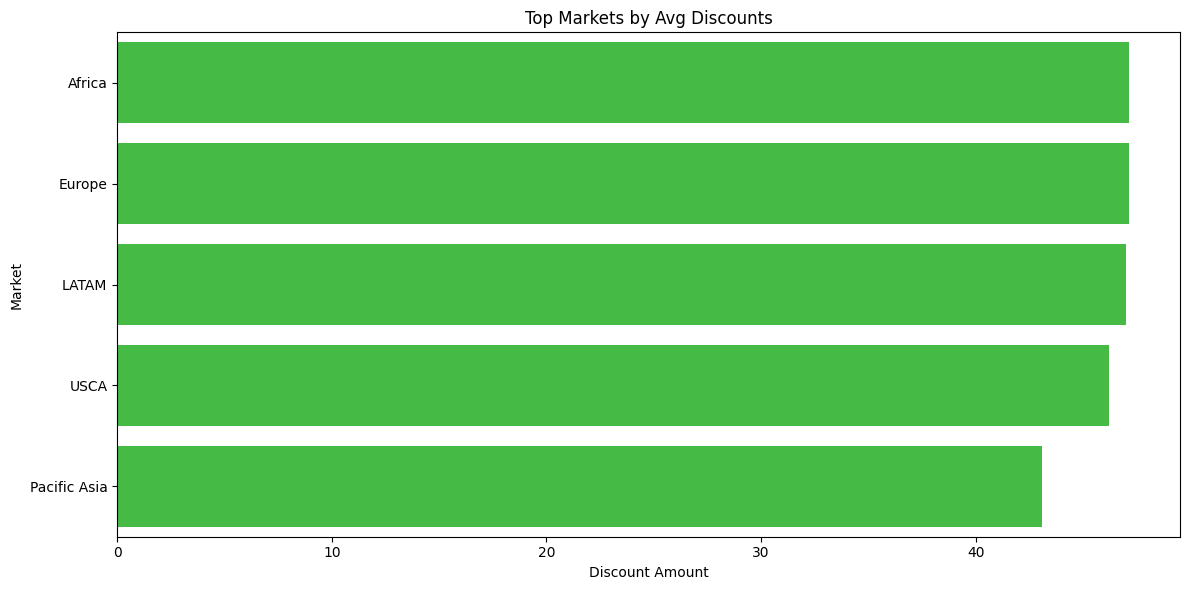

,market,discount_amount
0,Africa,47.16
1,Europe,47.13
2,LATAM,47.02
4,USCA,46.20
3,Pacific Asia,43.07


In [11]:
highest_avg_discount = (
        df.groupby("market")["discount_amount"]
          .mean()
          .round(2)
          .reset_index()
          .sort_values(by ="discount_amount", ascending = False)
)

plt.figure(figsize=(12,6))
sns.barplot(data = highest_avg_discount,
            x = "discount_amount",
            y = "market",
            color = "limegreen")
plt.title("Top Markets by Avg Discounts")
plt.xlabel("Discount Amount")
plt.ylabel("Market")
plt.tight_layout()
plt.show()
highest_avg_discount

-- Business Insight:

Africa offers the highest average discounts, suggesting stronger reliance on discounts compared to other markets.

Pacific Asia has the lowest average discount, indicating that sales in this market depend less on discounting than the others.

Which product categories contribute the highest and lowest sales revenue?

In [12]:
highest_lowest_sales =(
    df.groupby("category_name")["sales"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "sales", ascending = False)
)
highest_sales_category = highest_lowest_sales.head(1)
lowest_sales_category = highest_lowest_sales.tail(1)

highest_sales_category["Type"] = "Highest Sales"
lowest_sales_category ["Type"]= "Lowest Sales"

final_category = pd.concat ([highest_sales_category, lowest_sales_category], ignore_index= True)
final_category


,category_name,sales,Type
0,Fishing,6929653.69,Highest Sales
1,CDs,3059.59,Lowest Sales


-- Business Insight:

Fishing is the highest revenue-generating product category, indicating strong customer demand and making it a key contributor to the company's overall sales.

CDs generate the lowest sales revenue, suggesting limited customer demand and highlighting an opportunity to review product strategy, pricing, or inventory allocation.

Which customer segment generates the lowest sales revenue?

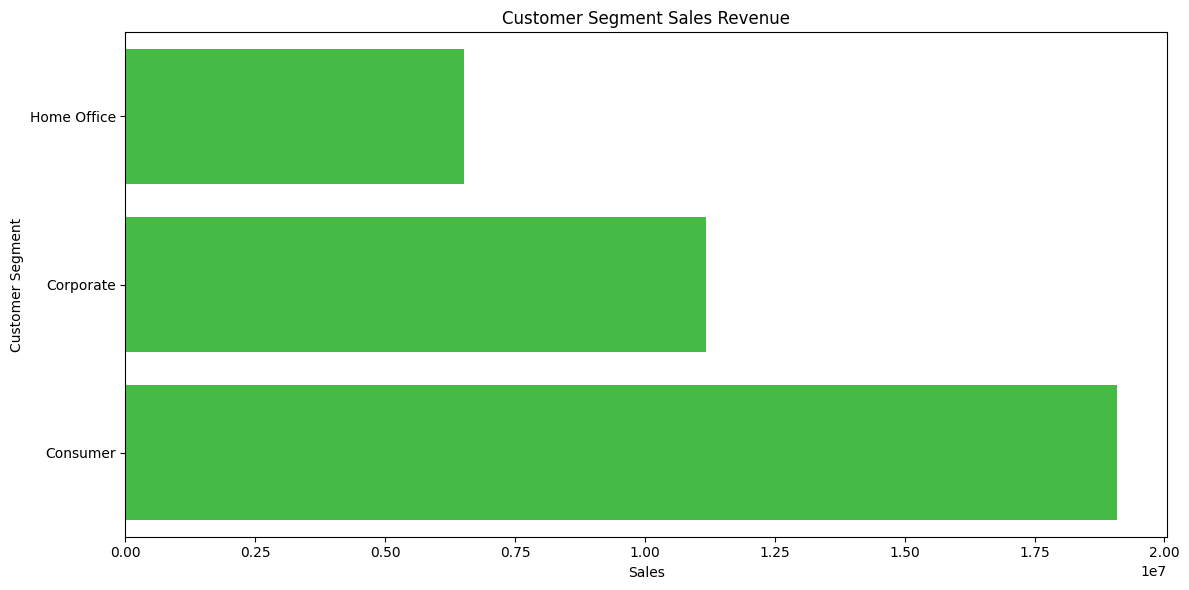

In [13]:
lowest_sales_revenue = (
    df.groupby("customer_segment")["sales"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = "sales", ascending = True)  
)

plt.figure(figsize=(12,6))
sns.barplot(data = lowest_sales_revenue,
            x= "sales",
            y="customer_segment",
            color = "limegreen")
plt.title("Customer Segment Sales Revenue")
plt.xlabel("Sales")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

-- Business Insights:

Home Office generates the lowest sales revenue among all customer segments, indicating lower purchasing activity compared to other segments.

Consumer is the highest revenue-generating customer segment, making it the primary contributor to the company's overall sales.

Which markets generate the lowest sales and profit?

In [14]:
lowest_sales_profit =(
    df.groupby("market")[["sales","order_profit_per_order"]]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = ["sales","order_profit_per_order"])
)
lowest_sales_profit

,market,sales,order_profit_per_order
0,Africa,2294452.93,252071.18
4,USCA,5066528.71,564313.78
3,Pacific Asia,8273743.74,857753.44
2,LATAM,10277612.84,1123321.61
1,Europe,10872396.80,1169442.96


-- Business Insights:

Africa generates the lowest sales and profit among all markets, indicating it is the weakest-performing market and may require targeted sales and marketing strategies.

Europe is the strongest-performing market, generating the highest sales and profit, making it a key contributor to the company's overall business performance.

Which countries generate the lowest sales and profit?

In [15]:
lowest_sales_profit =(
    df.groupby("order_country")[["sales","order_profit_per_order"]]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = ["sales","order_profit_per_order"])
      .head(10)
)
lowest_sales_profit

,order_country,sales,order_profit_per_order
131,Serbia,120.00,42.00
23,Burundi,299.95,77.75
44,Eritrea,309.96,92.48
62,Guinea Ecuatorial,319.96,103.36
82,Kuwait,334.96,133.83
7,Armenia,455.90,42.46
13,Baréin,529.89,150.22
29,Chad,599.96,-272.71
144,Sáhara Occidental,599.96,-17.52
83,Laos,683.01,84.09


-- Business Insights:

Serbia, Burundi, and Eritrea generate the lowest sales revenue, indicating very limited business activity in these countries.

Chad records one of the lowest sales volumes while also generating a negative total profit, suggesting that operations in this market may be unprofitable and require immediate review.

Are higher discounts leading to higher sales and profitability?

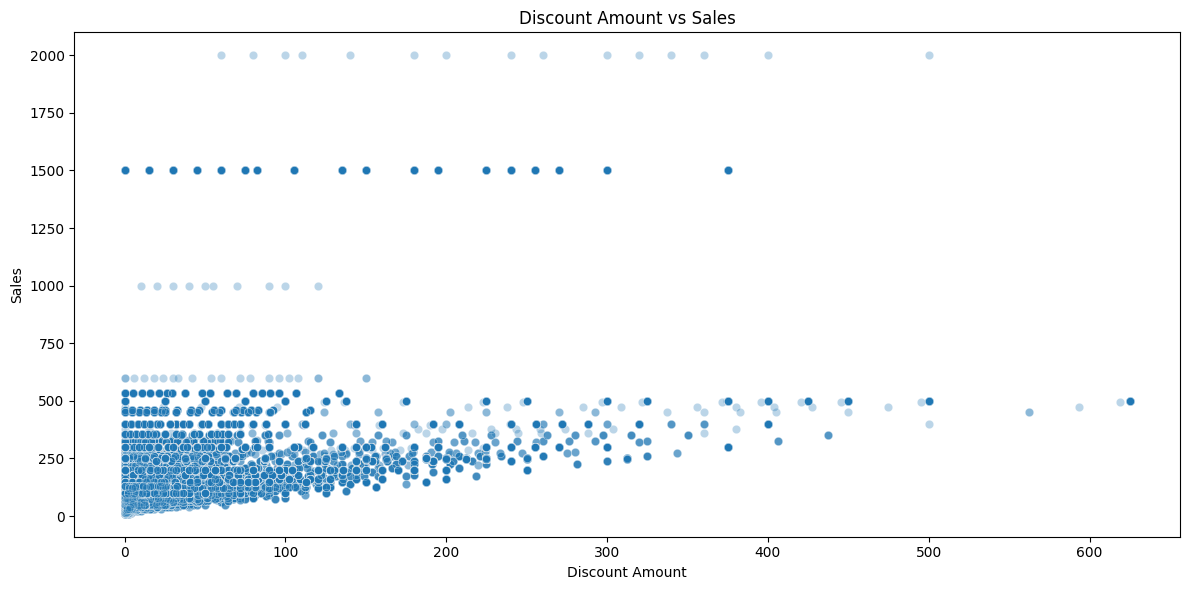

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data = df,
                x = "discount_amount",
                y = "sales",
                alpha = 0.3)

plt.title("Discount Amount vs Sales")
plt.xlabel("Discount Amount")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

-- Business Insights:

Giving bigger discounts does not always result in higher sales. Some products with small discounts still achieve high sales, while some heavily discounted products do not perform as well.

Discounts should be offered strategically rather than on every product. Offering discounts only on products that truly benefit from promotions can help increase sales while protecting profit.

Which products generate high sales but low profit?

In [17]:
high_sales_low_profit = (
    df.groupby("product_name")[["sales","order_profit_per_order"]]
      .sum()
      .round(2)
      .reset_index()
)
high_sales_low_profit["profit_margin"] = (
    high_sales_low_profit["order_profit_per_order"] / 
    high_sales_low_profit["sales"]*100
)
result = high_sales_low_profit.sort_values(by = ["sales","profit_margin"],
                                           ascending = [False,True]
)
result.head(10)


,product_name,sales,order_profit_per_order,profit_margin
24,Field & Stream Sportsman 16 Gun Fire Safe,6929653.69,756220.77,10.912822
71,Perfect Fitness Perfect Rip Deck,4421143.14,493828.30,11.169697
21,Diamondback Women's Serene Classic Comfort Bi,4118425.57,427455.57,10.379101
61,Nike Men's Free 5.0+ Running Shoe,3667633.20,379915.82,10.358610
59,Nike Men's Dri-FIT Victory Golf Polo,3147800.00,350421.03,11.132252
70,Pelican Sunstream 100 Kayak,3099845.09,324076.37,10.454599
56,Nike Men's CJ Elite 2 TD Football Cleat,2891757.66,311902.82,10.785925
67,O'Brien Men's Neoprene Life Vest,2888993.91,318451.43,11.022918
102,Under Armour Girls' Toddler Spine Surge Runni,1269082.67,126278.51,9.950377
18,Dell Laptop,663000.00,69656.81,10.506306


-- Business insight:

High-revenue products like Field & Stream Sportsman 16 Gun Fire Safe and Perfect Fitness Perfect Rip Deck generate significant sales but maintain moderate profit margins, indicating potential opportunities for cost reduction or pricing optimization.

Products such as Nike Men's Free 5.0+ Running Shoe and Diamondback Women's Serene Classic Comfort Bike have strong sales performance but lower margins, suggesting the company should review discounts, supplier costs, or pricing strategies.

Which product categories generate the lowest profit? 

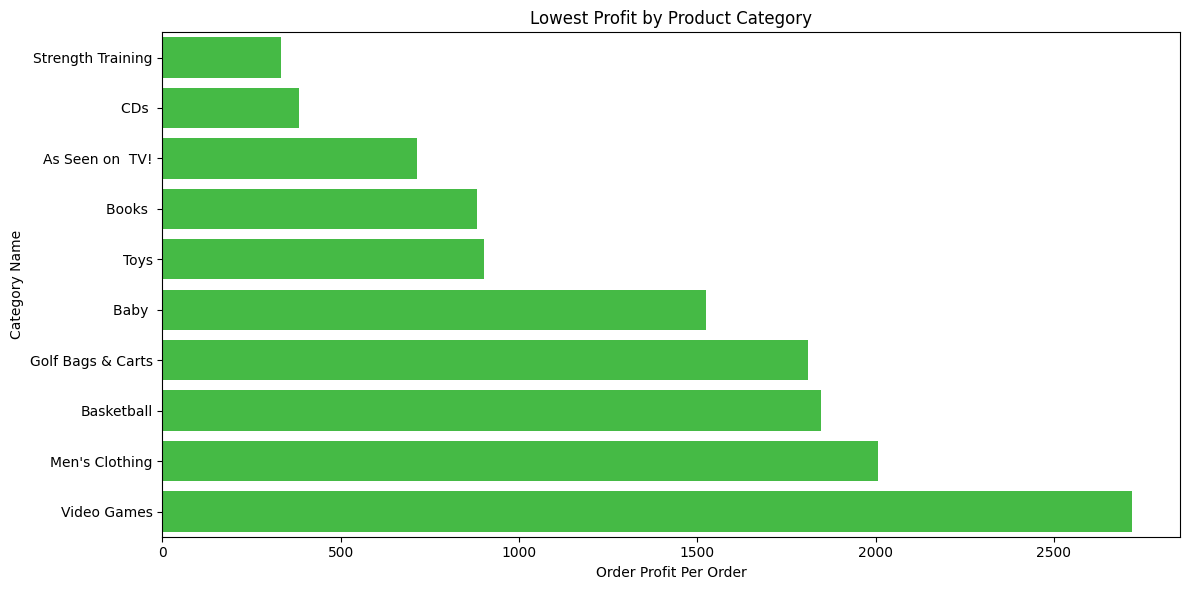

In [18]:
lowest_profit =(
    df.groupby("category_name")["order_profit_per_order"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(by = ["order_profit_per_order"])
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(data = lowest_profit,
            x = "order_profit_per_order",
            y = "category_name",
            color = "limegreen")
plt.title("Lowest Profit by Product Category")
plt.xlabel("Order Profit Per Order")
plt.ylabel("Category Name")
plt.tight_layout()
plt.show()

-- Business insight:

Strength Training, CDs, and As Seen on TV! categories contribute the lowest total profit, indicating these categories may require pricing, demand, or cost structure analysis.

Low-profit categories should be reviewed for improving margins through better pricing strategies, reducing costs, or optimizing product selection.

Which countries have the highest average delivery delay?

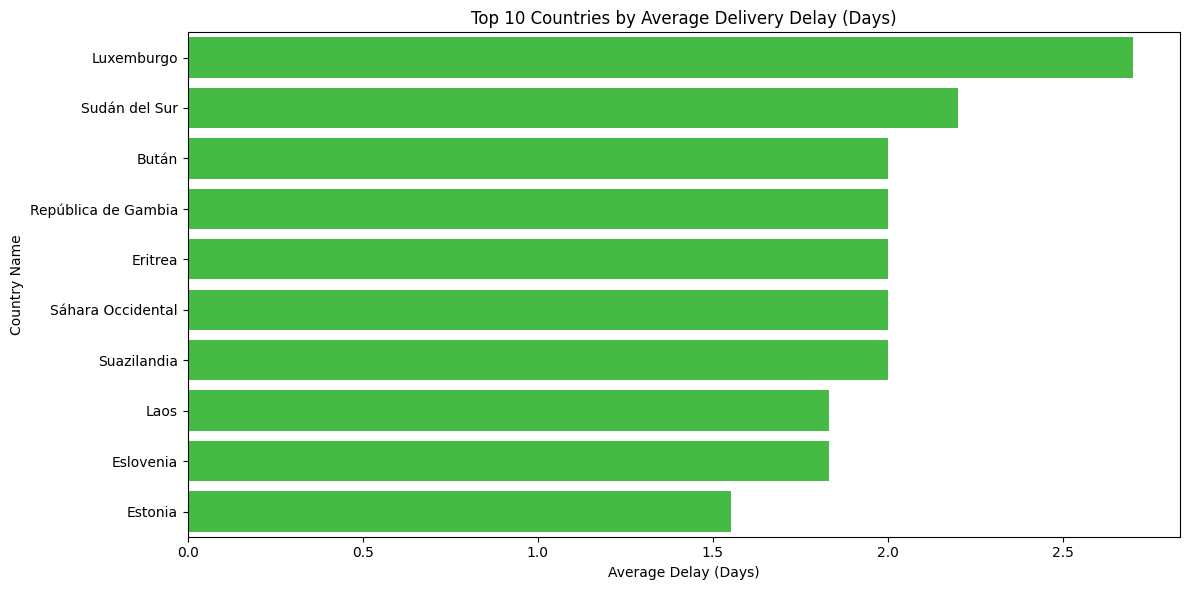

,order_country,delivery_delay_days
88,Luxemburgo,2.700000
140,Sudán del Sur,2.200000
24,Bután,2.000000
125,República de Gambia,2.000000
44,Eritrea,2.000000
144,Sáhara Occidental,2.000000
137,Suazilandia,2.000000
83,Laos,1.833333
46,Eslovenia,1.833333
49,Estonia,1.551724


In [19]:
late_delivery_rate = (
    df.groupby("order_country")["delivery_delay_days"]
      .mean()
      .reset_index()
      .sort_values(by = "delivery_delay_days", ascending = False)
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(data = late_delivery_rate,
            x = "delivery_delay_days",
            y = "order_country",
            color = "limegreen")
plt.title("Top 10 Countries by Average Delivery Delay (Days)")
plt.xlabel("Average Delay (Days)")
plt.ylabel("Country Name")
plt.tight_layout()
plt.show()
late_delivery_rate

-- Business Insight:

Luxemburgo has the highest average delivery delay (~2.7 days), indicating potential logistics or shipping efficiency issues in this market.

Countries with higher average delays should be investigated for possible problems related to shipping partners, transportation routes, or order fulfillment processes.

Which shipping mode has the highest average delivery delay?

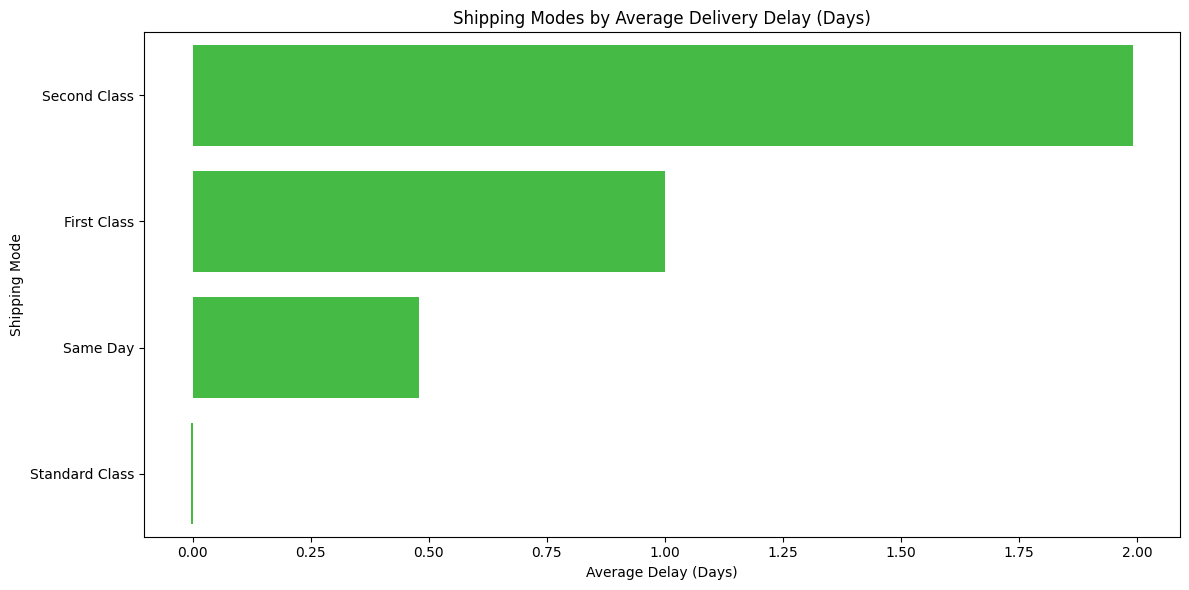

In [20]:
avg_delivery_delay = (
    df.groupby("shipping_mode")["delivery_delay_days"]
      .mean()
      .reset_index()
      .sort_values(by = "delivery_delay_days", ascending = False)
)
plt.figure(figsize=(12,6))
sns.barplot(data = avg_delivery_delay,
            x = "delivery_delay_days",
            y = "shipping_mode",
            color = "limegreen")
plt.title("Shipping Modes by Average Delivery Delay (Days)")
plt.xlabel("Average Delay (Days)")
plt.ylabel("Shipping Mode")
plt.tight_layout()
plt.show()

-- Business Insights:

Second Class shipments experience the longest delivery delays, suggesting that this shipping mode may require improvements in logistics, carrier performance, or route planning.

Standard Class has virtually no average delivery delay, indicating it is the most reliable shipping option in terms of meeting scheduled delivery dates.

Which customer segment experiences the highest average delivery delay?

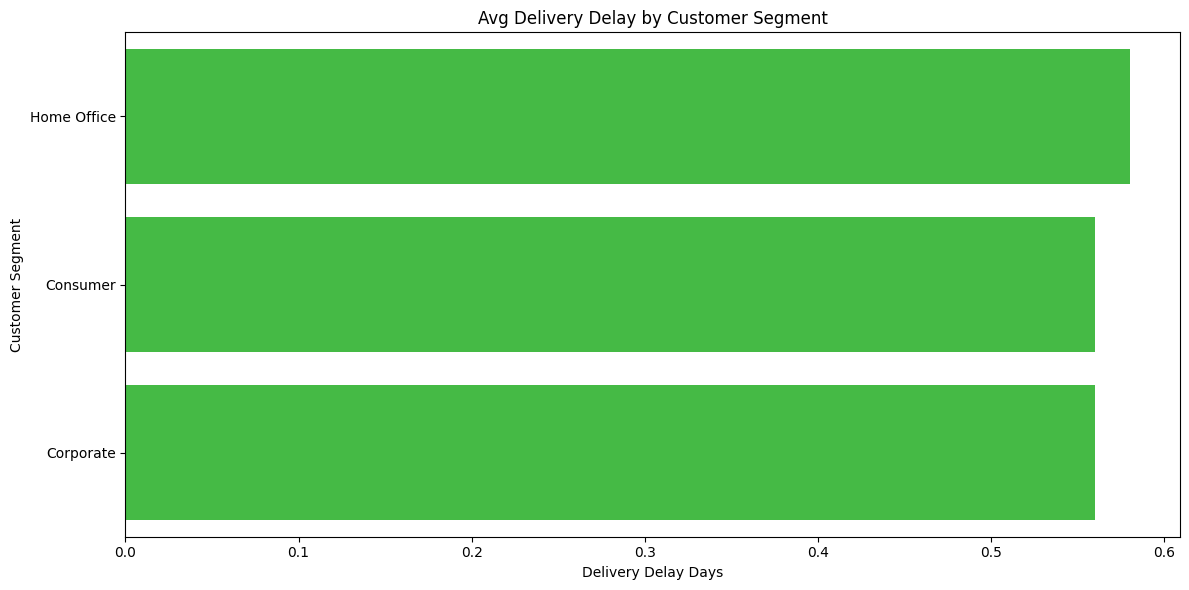

,customer_segment,delivery_delay_days
2,Home Office,0.58
0,Consumer,0.56
1,Corporate,0.56


In [21]:
avg_delivery_delay = (
    df.groupby("customer_segment")["delivery_delay_days"]
      .mean()
      .round(2)
      .reset_index()
      .sort_values(by = "delivery_delay_days", ascending = False)
)
plt.figure(figsize=(12,6))
sns.barplot(data = avg_delivery_delay,
            x = "delivery_delay_days",
            y = "customer_segment",
            color = "limegreen")
plt.title("Avg Delivery Delay by Customer Segment")
plt.xlabel("Delivery Delay Days")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()
avg_delivery_delay


-- Business Insights:

The Home Office segment has the highest average delivery delay (approximately 0.58 days), but the difference compared to the Consumer and Corporate segments is minimal.

Since delivery delays are nearly identical across all customer segments, shipping performance appears to be consistent. Efforts to reduce delays should focus on overall logistics rather than a specific customer segment.

Which market has the lowest average order value? 

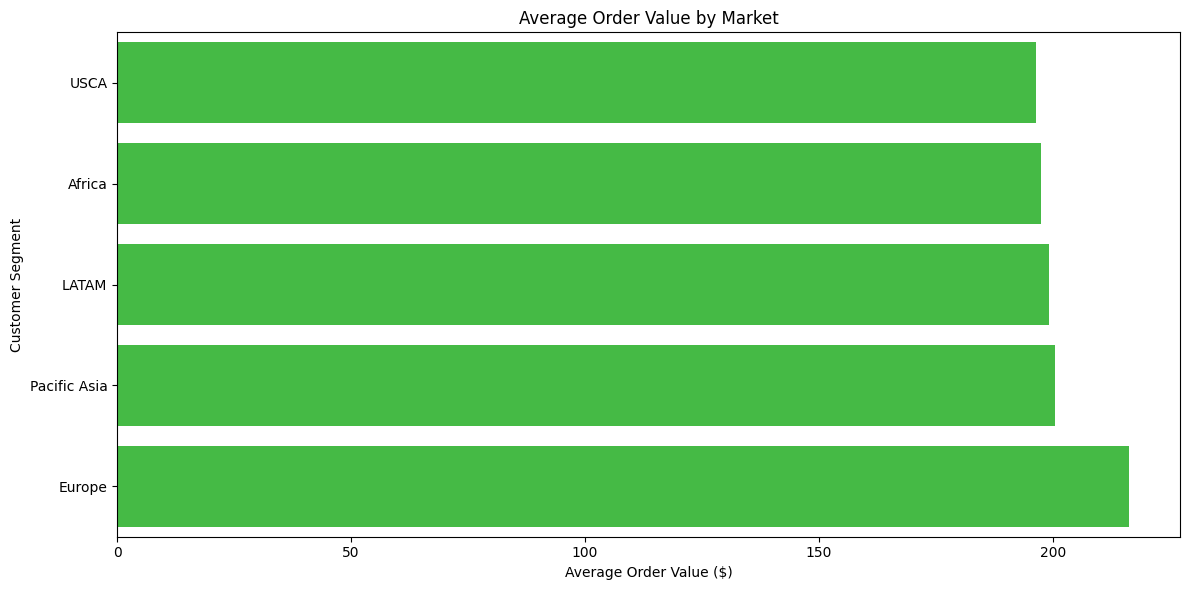

,market,sales
4,USCA,196.38
0,Africa,197.56
2,LATAM,199.20
3,Pacific Asia,200.53
1,Europe,216.36


In [23]:
avg_order_value=(
    df.groupby("market")["sales"]
      .mean()
      .round(2)
      .reset_index()
      .sort_values(by = "sales", ascending = True)
)
plt.figure(figsize=(12,6))
sns.barplot(data = avg_order_value,
            y = "market",
            x = "sales",
            color = "limegreen")
plt.title("Average Order Value by Market")
plt.xlabel("Average Order Value ($)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()
avg_order_value

-- Business Insights:

USCA records the lowest average order value ($196.38), indicating that customers in this market tend to place smaller orders than those in other markets.

Europe has the highest average order value ($216.36), suggesting greater customer spending per order and making it a strong market for premium products and upselling opportunities.

Which countries generate high sales but low profit?

In [24]:
country_sales_table = (
    df.groupby("order_country")[["sales", "order_profit_per_order"]]
      .sum()
      .round(2)
      .reset_index()
)
country_sales_table["profit_margin"] = (
    country_sales_table["order_profit_per_order"]
    / country_sales_table["sales"]) * 100

high_sales_low_profit = (
    country_sales_table.sort_values(by=["sales", "profit_margin"],ascending=[False, True])
)
high_sales_low_profit.head(10)


,order_country,sales,order_profit_per_order,profit_margin
48,Estados Unidos,4879667.67,540413.07,11.074793
53,Francia,2879942.36,327828.58,11.383165
102,México,2633195.29,303278.37,11.517504
2,Alemania,2074171.82,194827.08,9.393006
8,Australia,1694621.67,170041.58,10.034191
120,Reino Unido,1612094.85,180942.88,11.224084
20,Brasil,1594319.95,186713.64,11.711178
31,China,1172902.11,122190.92,10.417828
75,Italia,1072181.67,121545.47,11.336276
69,India,962396.70,99746.82,10.364418


-- Business Insights:

Germany generates over $2.07 million in sales but has the lowest profit margin (9.39%) among the top-selling countries, suggesting that high revenue is not translating into proportional profitability.

The company should investigate factors such as discounts, shipping costs, product mix, or operational expenses in Germany to improve profit margins without sacrificing sales performance.

Create a correlation heatmap of all numerical variables to identify key business relationships.

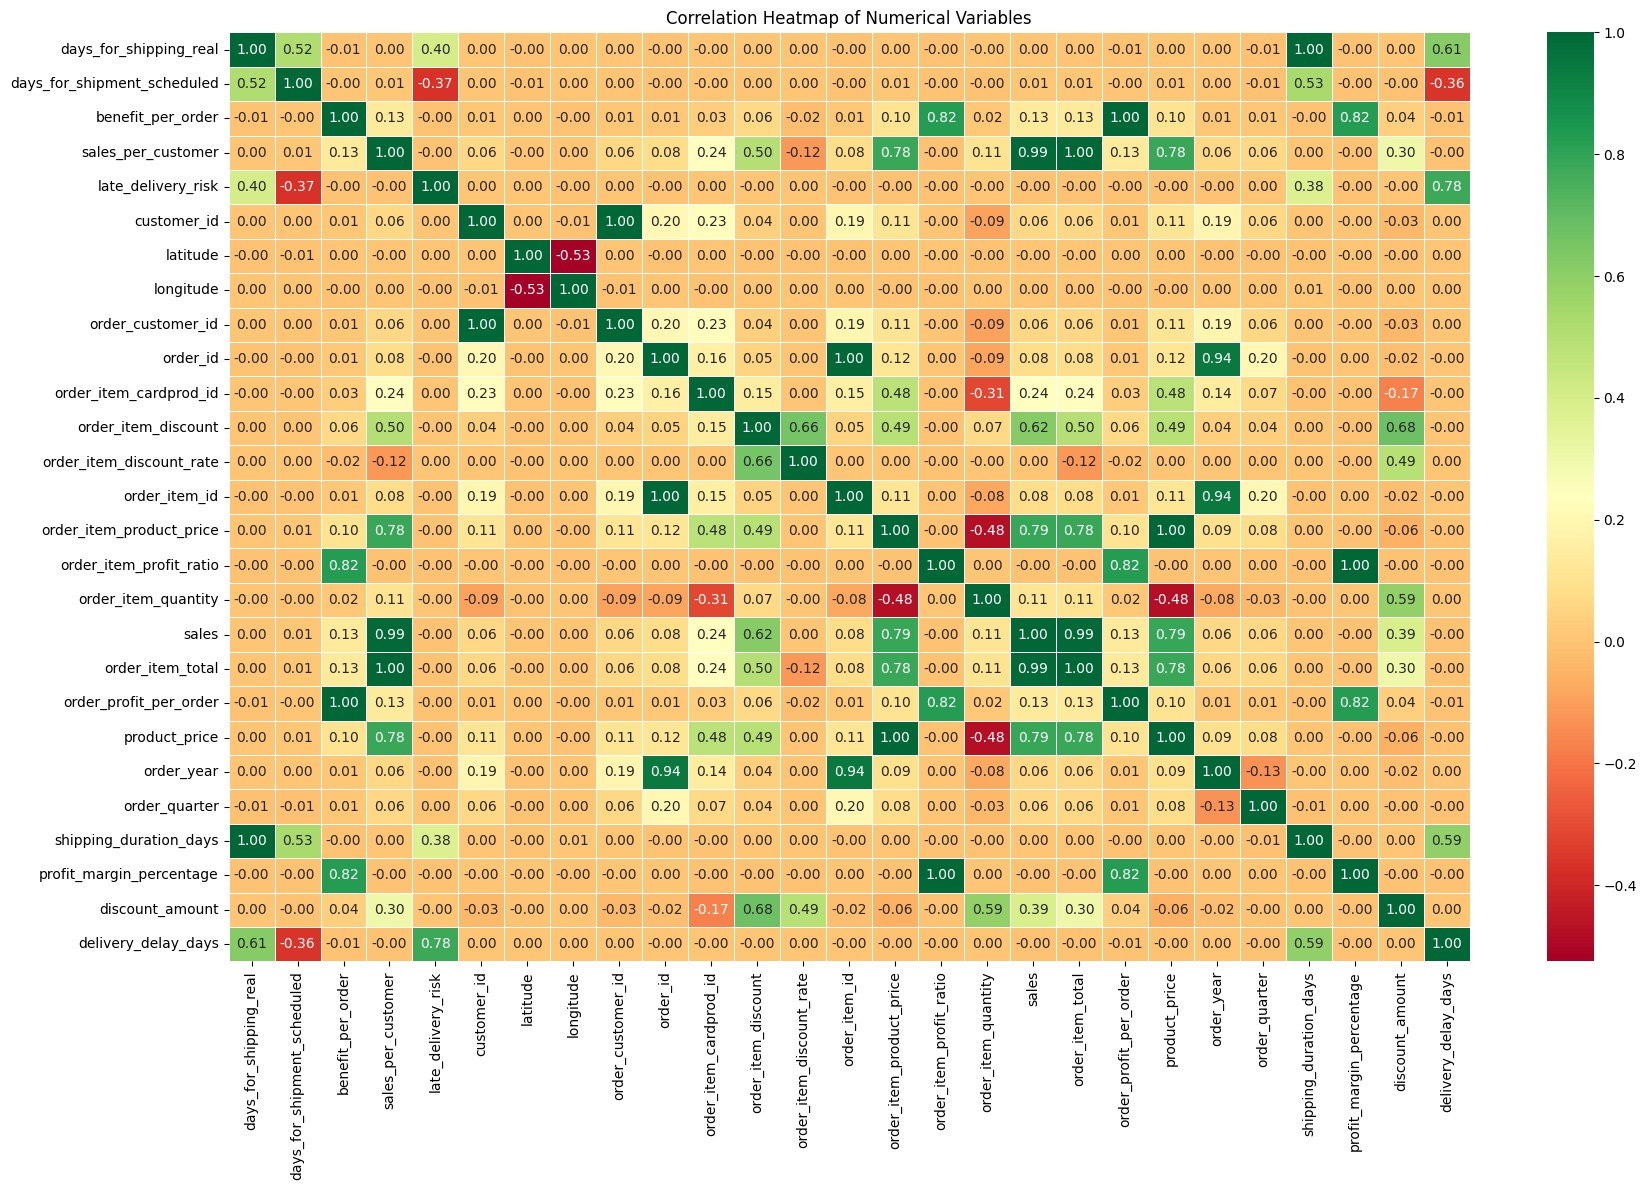

In [25]:
numerical_data = df.select_dtypes(include = "number")
corr_matrix = numerical_data.corr()
plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix,
            annot = True,
            fmt =".2f",
            cmap = "RdYlGn",
            linewidth = 0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

-- Business Insights:

Look for correlations such as:

Sales <> Order Profit: A strong positive correlation indicates that higher sales generally lead to higher profits.

Discount Rate <> Profit: A negative correlation suggests that higher discounts reduce profitability.

Quantity <> Sales: A positive correlation indicates that selling more items increases revenue.

Delivery Delay <> Late Delivery: A strong positive correlation confirms that longer delays are associated with a higher likelihood of late deliveries.

Conclusion

Overall, the Python analysis revealed valuable insights into the company's sales, profitability, customer behavior, and delivery performance. While several countries and markets generate strong sales, not all of them achieve equally high profitability, highlighting opportunities to improve profit margins. The analysis also identified differences in customer spending patterns and shipping performance, with some shipping modes experiencing longer delivery delays. These findings can help the business make better decisions on pricing, logistics, and operational efficiency, ultimately improving customer satisfaction and overall business performance.